## SỬ DỤNG MÔ HÌNH HỌC MÁY Để DỰ BÁO GIÁ TRỊ VÒNG ĐỜI CỦA KHÁCH HÀNG 


In [13]:
# =========================================================
# IMPORT LIBRARIES & SETUP
# =========================================================

# Core & Data Manipulation
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning: Models & Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor

# Machine Learning: Preprocessing & Feature Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Machine Learning: Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# System & Notebook Configs
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo rác màu đỏ khi chạy model

# Thiết lập style mặc định cho biểu đồ đẹp hơn
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline


In [14]:
df = pd.read_csv('Dataset/Cleaned_data/master_df.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CustomerID             52924 non-null  int64  
 1   Transaction_ID         52924 non-null  int64  
 2   Transaction_Date       52924 non-null  object 
 3   Month                  52924 non-null  object 
 4   Date                   52924 non-null  object 
 5   Week                   52924 non-null  object 
 6   Product_SKU            52924 non-null  object 
 7   Product_Description    52924 non-null  object 
 8   Product_Category       52924 non-null  object 
 9   ABC                    52924 non-null  object 
 10  Quantity               52924 non-null  int64  
 11  Avg_Price              52924 non-null  float64
 12  Delivery_Charges       52924 non-null  float64
 13  Revenue                52924 non-null  float64
 14  total_revenue          52924 non-null  float64
 15  In

## Time Split trong CLV Prediction

**Mục đích**: Chia dữ liệu theo thời gian để mô hình học từ quá khứ, dự đoán tương lai.

**Các bước**:
  - Chuyển `Transaction_Date` thành datetime.
  - `end_date`: Ngày cuối cùng.
  - `cutoff_date`: end_date - 90 ngày.
  - `cal_df`: Dữ liệu ≤ cutoff_date (huấn luyện).
  - `holdout_df`: Dữ liệu > cutoff_date (kiểm tra CLV thực tế).
  - `recent_df`: Giao dịch 30 ngày gần nhất trong cal_df (hành vi gần đây).

**Ý nghĩa**: Đảm bảo đánh giá khách quan, nắm bắt xu hướng gần đây.

In [15]:
# =========================================================
# TIME SPLIT
# =========================================================
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

end_date = df['Transaction_Date'].max()
cutoff_date = end_date - pd.Timedelta(days=90)

cal_df = df[df['Transaction_Date'] <= cutoff_date].copy()
holdout_df = df[df['Transaction_Date'] > cutoff_date].copy()

# Recent window (30 days before cutoff)
recent_cutoff = cutoff_date - pd.Timedelta(days=30)

recent_df = cal_df[
    cal_df['Transaction_Date'] >= recent_cutoff
].copy()

## Base Features trong CLV Prediction

**Mục đích**: Tạo các đặc trưng cơ bản cho mỗi khách hàng từ dữ liệu giao dịch trong calibration period.

**Cách làm**: Group by `CustomerID` và aggregate các chỉ số:
  - **RFM cơ bản**: first_purchase, last_purchase, frequency, monetary_sum
  - **Hành vi mua**: total_quantity, unique_categories, avg_discount, coupon_usage
  - **Chi phí**: delivery_fee, offline/online spend, marketing spend
  - **Thông tin khách**: Tenure_Months, Gender, Location, KMeans_Label

**Ý nghĩa**: Chuyển dữ liệu giao dịch thành profile khách hàng để mô hình học.

In [16]:
# =========================================================
# BASE FEATURES
# =========================================================
features = cal_df.groupby('CustomerID').agg(
    
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),

    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),

    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),

    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),

    total_delivery_fee=('Delivery_Charges', 'sum'),

    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),

    Tenure_Months=('Tenure_Months', 'first'),

    Gender=('Gender', 'first'),
    Location=('Location', 'first'),

    KMeans_Label=('KMeans_Label', 'first')

).reset_index()

## RFM + Recent Features

**Ý tưởng chính**: Tạo các chỉ số đo lường hành vi và đặc điểm khách hàng để dự đoán CLV.
- **Recency (recency_cal)**: Khách hàng đã bao lâu không mua? → Thể hiện mức độ active gần đây.
- **Customer Age (T_cal)**: Khách hàng đã là thành viên bao lâu? → Khách cũ thường có giá trị cao hơn.
- **Average Order Value (monetary_avg)**: Trung bình mỗi đơn hàng khách chi bao nhiêu? → Đo giá trị đơn lẻ.
- **Purchase Frequency (avg_order_interval)**: Khoảng cách trung bình giữa các lần mua → Khách mua đều đặn hay theo đợt?

**Ý tưởng về hành vi gần đây**: Hành vi gần đây quan trọng hơn hành vi cũ. Khách hàng có thể thay đổi thói quen theo thời gian.
- **freq_last30**: Số lần mua trong 30 ngày gần nhất → Khách có còn mua đều không?
- **spend_last30**: Tổng chi tiêu 30 ngày gần nhất → Mức độ đầu tư gần đây.
- **qty_last30**: Tổng số lượng sản phẩm mua gần đây → Cường độ mua hàng.

**Ý nghĩa kinh doanh**: Những chỉ số này giúp phân loại khách hàng và dự đoán xu hướng chi tiêu tương lai, đặc biệt là phát hiện khách hàng đang "hot" hay đang "chậm lại".

In [17]:
# =========================================================
# RFM + CUSTOMER AGE FEATURES
# =========================================================
features['recency_cal'] = (
    cutoff_date - features['last_purchase']
).dt.days

features['T_cal'] = (
    cutoff_date - features['first_purchase']
).dt.days

features['monetary_avg'] = (
    features['monetary_sum'] /
    (features['frequency_cal'] + 1)
)

features['avg_order_interval'] = (
    features['T_cal'] /
    (features['frequency_cal'] + 1)
)

In [18]:
# =========================================================
# RECENT TREND FEATURES (LAST 30 DAYS)
# =========================================================
recent_features = recent_df.groupby('CustomerID').agg(
    
    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')

).reset_index()


features = pd.merge(
    features,
    recent_features,
    on='CustomerID',
    how='left'
)


# fill missing customers
recent_cols = [
    'freq_last30',
    'spend_last30',
    'qty_last30'
]

features[recent_cols] = (
    features[recent_cols]
    .fillna(0)
)

## Momentum Features - Bắt Lấy Xu Hướng Thay Đổi

Cho đến giờ, chúng ta có dữ liệu về lịch sử mua hàng toàn bộ của khách hàng. Nhưng có một câu hỏi quan trọng: **Khách hàng này đang mua nhiều hơn hay ít hơn so với trước?**

Momentum features giúp trả lời câu hỏi đó bằng cách so sánh hành vi gần đây với hành vi trung bình.

### Purchase Momentum
- **Công thức**: `freq_last30 / frequency_cal`
- **Ý nghĩa**: Tỷ lệ giữa tần suất mua gần đây và trung bình lịch sử
  - Nếu = 1: Khách mua với tần suất bình thường
  - Nếu > 1: Khách mua **nhiều hơn** gần đây (tín hiệu tích cực)
  - Nếu < 1: Khách mua **ít hơn** gần đây (tín hiệu cảnh báo)

### Spend Momentum
- **Công thức**: `spend_last30 / monetary_sum`
- **Ý nghĩa**: Tỷ lệ giữa chi tiêu gần đây và chi tiêu trung bình lịch sử
  - Phản ánh xu hướng: khách có tăng ngân sách hay giảm ngân sách?

### Tại Sao Momentum Quan Trọng?
Một khách hàng có thể có lịch sử tốt (lịch sử dài, chi tiêu nhiều), nhưng nếu momentum thấp, có nghĩa là họ đang "nguội đi". Ngược lại, một khách mới có momentum cao có thể là "sao mai" với tiềm năng cao.

In [19]:
# =========================================================
# MOMENTUM FEATURES
# =========================================================
features['purchase_momentum'] = (
    features['freq_last30'] /
    (features['frequency_cal'] + 1)
)

features['spend_momentum'] = (
    features['spend_last30'] /
    (features['monetary_sum'] + 1)
)

## Xử Lý Dữ Liệu cho ML

**Loại bỏ cột ngày**: `first_purchase` và `last_purchase` đã được dùng để tính các features (recency, T_cal). Giữ lại cột ngày sẽ làm lộ thông tin thời gian trực tiếp, mô hình không cần.

**Mã hóa biến phân loại**: Chuyển Gender, Location, KMeans_Label thành dạng số (one-hot encoding) để mô hình có thể học. Bỏ một danh mục mỗi biến để tránh multicollinearity.

In [20]:
# =========================================================
# DROP DATE COLUMNS
# =========================================================
features = features.drop(
    columns=[
        'first_purchase',
        'last_purchase'
    ]
)

# =========================================================
# ENCODE CATEGORICAL
# =========================================================
features = pd.get_dummies(
    features,
    columns=[
        'Gender',
        'Location',
        'KMeans_Label'
    ],
    drop_first=True
)

## Tạo Target CLV

Từ holdout period (90 ngày sau cutoff_date), tính tổng chi tiêu của mỗi khách hàng. Đây là giá trị thực tế CLV mà mô hình sẽ dự đoán. Merge với features và fill 0 cho khách không mua trong period này.

In [21]:
# =========================================================
# TARGET (NEXT 90 DAYS CLV)
# =========================================================
target = holdout_df.groupby('CustomerID').agg(
    actual_clv_90d=('total_revenue', 'sum')
).reset_index()


ml_df = pd.merge(
    features,
    target,
    on='CustomerID',
    how='left'
)

ml_df['actual_clv_90d'] = (
    ml_df['actual_clv_90d']
    .fillna(0)
)

In [22]:
# =========================================================
# TRAIN / TEST SPLIT
# =========================================================
X = ml_df.drop(
    columns=[
        'CustomerID',
        'actual_clv_90d'
    ]
)

# giữ scale gốc trước, dễ interpret
y = ml_df['actual_clv_90d'].copy()

# Cap outliers (99th percentile)
upper = y.quantile(0.98)

y = np.clip(
    y,
    0,
    upper
)

print(f"Target capped at: {upper:.2f}")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Target capped at: 6642.72


## Huấn Luyện & Đánh Giá Mô Hình CLV

Sau khi chuẩn bị đầy đủ dữ liệu và features, bước tiếp theo là xây dựng và tối ưu hóa các mô hình máy học để dự đoán CLV. Quá trình này gồm 3 bước chính:

---

### Bước 1: Chuẩn Bị Dữ Liệu cho Mô Hình

**Tách Features và Target**
- Tách `X` (tất cả features sau khi encode) và `y` (actual_clv_90d)
- Loại bỏ `CustomerID` (chỉ để tracking) và nhãn mục tiêu khỏi X
- Giữ nguyên scale gốc của y để dễ interpret kết quả

**Xử Lý Outliers**
- Cap (giới hạn) các giá trị CLV cực đại ở percentile 98
- **Lý do**: Một vài khách hàng có chi tiêu cực lớn (e.g., đặt hàng sỉ) có thể làm mô hình học theo những pattern không đại diện
- **Tác động**: Giảm RMSE và cải thiện R² score vì mô hình tập trung vào phần lớn khách hàng

**Chia Train/Test**
- Split: 80% train, 20% test với `random_state=42` để đảm bảo reproducibility
- Mô hình sẽ học từ 80% dữ liệu huấn luyện
- Đánh giá trên 20% test set chưa nhìn thấy để kiểm tra khả năng tổng quát hóa

---

### Bước 2: Cấu Hình & So Sánh 3 Mô Hình Dự Đoán

Chúng ta sử dụng **3 mô hình tree-based** vì:
- Tree-based models xử lý tốt dữ liệu không cân bằng (imbalanced target)
- Tự động capture interaction giữa features
- Robust với outliers (sau khi cap)
- Dễ interpret feature importance

**1. Random Forest**
- **Đặc điểm**: Ensemble của nhiều decision trees, mỗi cây học từ random subset của dữ liệu
- **Hyperparameter tuning**:
  - `n_estimators`: [100, 200, 300] - số lượng cây
  - `max_depth`: [4, 6, 8, 10, None] - độ sâu của mỗi cây
  - `min_samples_split`: [2, 5, 10] - minimum samples để split node
  - `min_samples_leaf`: [1, 2, 4] - minimum samples ở leaf node
- **Ưu điểm**: Nhanh, ít bị overfitting, dễ train
- **Nhược điểm**: Có thể kém hiệu quả với non-linear patterns phức tạp

**2. Gradient Boosting**
- **Đặc điểm**: Xây dựng trees tuần tự, mỗi tree sửa lỗi của những trees trước
- **Hyperparameter tuning**:
  - `n_estimators`: [100, 200, 300] - số lượng iterations
  - `learning_rate`: [0.01, 0.05, 0.1, 0.2] - học từng bước nhỏ hay lớn
  - `max_depth`: [3, 4, 5, 6] - độ sâu cây (thường nhỏ hơn Random Forest)
  - `subsample`: [0.7, 0.8, 0.9, 1.0] - tỷ lệ dữ liệu dùng mỗi iteration
- **Ưu điểm**: Thường cho kết quả tốt hơn, capture patterns phức tạp
- **Nhược điểm**: Tính toán chậm hơn, dễ overfitting nếu không cẩn thận

**3. XGBoost (Extreme Gradient Boosting)**
- **Đặc điểm**: Gradient boosting cải tiến với regularization tốt hơn, tối ưu hóa GPU
- **Hyperparameter tuning**:
  - Tương tự GB nhưng thêm `colsample_bytree`: [0.7, 0.8, 0.9, 1.0] - tỷ lệ features mỗi tree
- **Ưu điểm**: Nhanh nhất, kết quả thường tốt nhất, xử lý outliers tốt
- **Nhược điểm**: Phức tạp hơn, cần tuning cẩn thận

---

### Bước 3: Huấn Luyện & Tối Ưu Hóa Tham Số

**Sử dụng RandomizedSearchCV**
- Thay vì thử tất cả combination (exhaustive grid search), random search chỉ thử 15 combinations ngẫu nhiên
- **Lợi ích**: Tiết kiệm thời gian tính toán đáng kể (từ hàng giờ xuống phút)
- **Cross-Validation**: k-fold CV = 3, chia train set thành 3 folds, validate lần lượt trên mỗi fold
- **Scoring metric**: Tối ưu hóa trên `neg_mean_absolute_error` (MAE) vì thường phù hợp hơn cho dữ liệu regression không cân bằng

**Quy trình cho mỗi mô hình**:
1. Fit RandomizedSearchCV trên `X_train` và `y_train`
2. Lấy `best_estimator_` (mô hình có tham số tốt nhất)
3. Dự đoán trên `X_test`
4. Clamp predictions (không cho phép giá trị âm vì CLV không thể âm)
5. Tính 3 metrics đánh giá:
   - **MAE (Mean Absolute Error)**: Sai số tuyệt đối trung bình (dễ interpret)
   - **RMSE (Root Mean Squared Error)**: Penalize lớn hơn các lỗi lớn
   - **R² Score**: Tỷ lệ variance được giải thích (từ 0 đến 1, cao hơn tốt hơn)

**Phân Tích Feature Importance**
- Sau khi train, lấy `feature_importances_` từ best model
- Sort top 15 features quan trọng nhất
- Giúp hiểu biến nào ảnh hưởng mạnh nhất đến CLV
- **Ví dụ**: KMeans_Label, Frequency, spend_last30 thường là top features

---

### Tóm Tắt Kết Quả Cuối Cùng

So sánh 3 mô hình trên test set:
- Sắp xếp theo R² Score (cao nhất xuống thấp nhất)
- Chọn mô hình có R² cao nhất, MAE thấp nhất để deploy
- Thường XGBoost cho kết quả tốt nhất cho bài toán CLV prediction

In [23]:
# =========================================================
# MODELS + PARAMETER SEARCH
# =========================================================
models_and_params = {

    "Random Forest": {
        "model": RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'max_depth': [4, 6, 8, 10, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4]
        }
    },

    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            random_state=42
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0]
        }
    },

    "XGBoost": {
        "model": XGBRegressor(
            random_state=42,
            n_jobs=-1
        ),
        "params": {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.7, 0.8, 0.9, 1.0],
            'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
        }
    }
}

In [24]:
# =========================================================
# TRAIN + EVALUATE
# =========================================================
results = []

print("\n--- START TRAINING ---")

for name, mp in models_and_params.items():

    print(f"\nTuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=mp["model"],
        param_distributions=mp["params"],
        n_iter=15,
        scoring='neg_mean_absolute_error',
        cv=3,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    best_model = random_search.best_estimator_
    # Feature importance (chỉ in cho XGBoost)
        
    importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': best_model.feature_importances_
    }).sort_values(
        by='importance',
        ascending=False
    )

    print("\nTop 15 Important Features:")
    print(importance.head(15))

    print(
        "Best Params:",
        random_search.best_params_
    )

    # Predict
    y_pred = best_model.predict(X_test)

    # no negative CLV
    y_pred = np.maximum(
        y_pred,
        0
    )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    print(
        f"MAE: {mae:.2f} | "
        f"RMSE: {rmse:.2f} | "
        f"R2: {r2:.4f}"
    )


# =========================================================
# FINAL RESULTS
# =========================================================
results_df = pd.DataFrame(
    results
).sort_values(
    by='R2 Score',
    ascending=False
)

print("\n--- FINAL RESULTS ---")
print(
    results_df.to_string(
        index=False
    )
)

print("\n---BEST MODEL---")
best_model = results_df.iloc[0]['Model']
print(best_model)


--- START TRAINING ---

Tuning Random Forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               feature  importance
26      KMeans_Label_2    0.229101
25      KMeans_Label_1    0.156868
11         recency_cal    0.108406
1         monetary_sum    0.100956
6   total_delivery_fee    0.088310
9      total_marketing    0.044221
2       total_quantity    0.036824
7        total_offline    0.032699
13        monetary_avg    0.027066
8         total_online    0.024822
10       Tenure_Months    0.021925
5    coupon_usage_rate    0.020424
3    unique_categories    0.019389
12               T_cal    0.018825
14  avg_order_interval    0.018655
Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 6}
MAE: 502.36 | RMSE: 987.61 | R2: 0.6259

Tuning Gradient Boosting...
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Top 15 Important Features:
               feature  importance
26      KMe

## Đánh giá và Kiểm định Mô hình (Model Validation)

**Mục tiêu:** 
Trước khi sử dụng mô hình Random Forest để dự báo CLV cho tương lai, chúng ta cần kiểm định mức độ chính xác của nó trên tập dữ liệu Test (những dữ liệu mô hình chưa từng được "nhìn" thấy trong quá trình huấn luyện). Việc trực quan hóa sai số giúp chúng ta có cái nhìn khách quan về hiệu suất của mô hình.

**Ý nghĩa của các biểu đồ:**
1. **Biểu đồ Scatter (Actual vs. Predicted):**
   - Trục X là CLV thực tế, trục Y là CLV do mô hình dự báo.
   - **Đường nét đứt màu đỏ (y=x)** đại diện cho mức "Dự báo hoàn hảo" (Actual = Predicted).
   - Nếu các điểm dữ liệu (màu xanh) càng bám sát vào đường màu đỏ này, chứng tỏ mô hình dự báo càng chính xác. Nếu các điểm phân tán quá xa, mô hình đang có sự sai lệch lớn.

2. **Biểu đồ Histogram (Phân phối phần dư - Residuals):**
   - Phần dư (Residual) chính là sai số: `Giá trị thực tế - Giá trị dự báo`.
   - **Đường nét đứt màu đỏ** đại diện cho mức sai số bằng 0.
   - Một mô hình tốt sẽ có biểu đồ phân phối hình quả chuông (Normal Distribution) hội tụ xoay quanh mốc 0. Nếu đỉnh của biểu đồ lệch sang trái hoặc phải quá nhiều, nghĩa là mô hình đang có xu hướng thiên lệch (thường xuyên dự báo quá cao hoặc quá thấp).


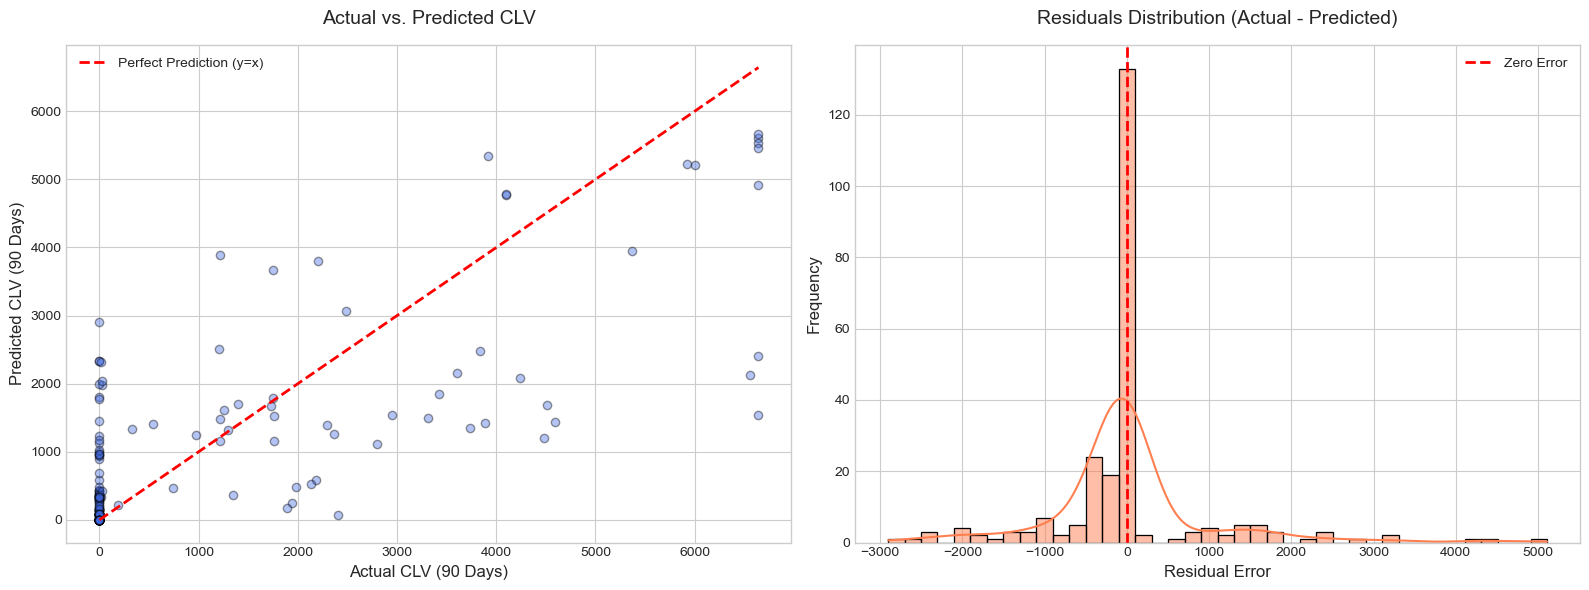

In [25]:
# =========================================================
# MODEL PREDICTION VALIDATION PLOTS
# =========================================================

# Khởi tạo và Huấn luyện lại mô hình để tránh lỗi "not defined"
best_model_estimator = RandomForestRegressor(
    n_estimators=200,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
best_model_estimator.fit(X_train, y_train)

# Dự đoán trên tập Test để đánh giá khách quan
y_pred_test = best_model_estimator.predict(X_test)
y_pred_test = np.maximum(y_pred_test, 0) # Không cho phép CLV âm

# Tính sai số (Residuals)
residuals = y_test - y_pred_test

# Thiết lập phong cách đồ thị
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# 1. Biểu đồ Scatter: Thực tế vs Dự đoán
# ---------------------------------------------------------
axes[0].scatter(y_test, y_pred_test, alpha=0.4, color='royalblue', edgecolor='k')

# Vẽ đường kỳ vọng (Perfect prediction line: y = x)
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')

axes[0].set_title('Actual vs. Predicted CLV', fontsize=14, pad=15)
axes[0].set_xlabel('Actual CLV (90 Days)', fontsize=12)
axes[0].set_ylabel('Predicted CLV (90 Days)', fontsize=12)
axes[0].legend()

# ---------------------------------------------------------
# 2. Biểu đồ Histogram: Phân phối của phần dư (Residuals)
# ---------------------------------------------------------
sns.histplot(residuals, kde=True, ax=axes[1], color='coral', bins=40)

# Vẽ đường trung tâm tại 0
axes[1].axvline(x=0, color='r', linestyle='--', lw=2, label='Zero Error')

axes[1].set_title('Residuals Distribution (Actual - Predicted)', fontsize=14, pad=15)
axes[1].set_xlabel('Residual Error', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

Dựa vào hai biểu đồ Validation, chúng ta có thể rút ra những đánh giá quan trọng về khả năng dự báo của mô hình Random Forest:

**1. Điểm tích cực (Khả năng dự báo cơ bản):**
- Biểu đồ **Histogram (Phân phối phần dư)** có một đỉnh chóp rất cao và nhọn hội tụ ngay tại mốc `Zero Error` (màu đỏ). Điều này chứng tỏ với đại đa số khách hàng tiêu chuẩn (Standard), mô hình dự báo rất tốt, sai số cực kỳ thấp. Tổng thể mô hình không bị lệch tâm (không bị thiên kiến quá mức về một phía).

**2. Hạn chế của mô hình (Những rủi ro tiềm ẩn):**
Quan sát biểu đồ **Scatter Plot**, chúng ta phát hiện hai vấn đề lớn mang tính đặc thù của thuật toán Random Forest đối với dữ liệu tài chính:
- **Over-prediction ở nhóm khách hàng ngưng giao dịch (Actual = 0):** Rất nhiều điểm dữ liệu nằm trên trục Y (Thực tế = 0) nhưng lại được mô hình dự báo sẽ chi tiêu từ $1,000 đến $3,000. Điều này rất nguy hiểm cho Marketing, vì nếu tin tưởng hoàn toàn, chúng ta sẽ lãng phí ngân sách Retargeting cho những khách hàng đã thực sự rời bỏ (Churn).
- **Under-prediction ở nhóm siêu VIP (Whales):** Với những khách hàng tiêu xài cực lớn (Thực tế > $4,000), các điểm màu xanh thường nằm chìm sâu bên dưới đường nét đứt màu đỏ. Nghĩa là mô hình dự báo quá "rụt rè" và đánh giá thấp tiềm năng của nhóm này. Nguyên nhân là do Random Forest sử dụng cơ chế lấy trung bình (Average) của nhiều cây quyết định, khiến nó không bao giờ dự báo ra được các giá trị cực đoan (Outliers).

**3. Đề xuất & Lưu ý khi ứng dụng vào thực tế:**
Nếu sử dụng kết quả dự báo CLV này cho các chiến dịch Marketing trong tương lai, cần lưu ý:
- **Nên kết hợp với Mô hình Churn:** Không nên tin 100% vào giá trị CLV của những khách hàng có tín hiệu ngừng mua. Có thể xây dựng thêm một mô hình Phân loại (Classification) dự đoán xác suất khách hàng quay lại. Nếu xác suất quay lại < 20%, nên chủ động gán CLV tương lai của họ bằng 0.
- **Tiếp cận rủi ro với nhóm VIP:** Danh sách Top 10 khách hàng VIP mô hình chỉ ra là hoàn toàn có cơ sở, nhưng số tiền thực tế họ mang lại có thể còn **lớn hơn rất nhiều** so với con số mô hình dự báo.
- **Hướng cải thiện (Next steps):** Trong các phiên bản tối ưu tiếp theo, có thể thử nghiệm mô hình 2 bước (Two-stage model: Phân loại mua/không mua -> Hồi quy số tiền) hoặc sử dụng các thuật toán chuyên dụng cho CLV như *Buy 'Til You Die (BTYD / BG-NBD)* để khắc phục điểm yếu của Random Forest.


## Top 10 Khách Hàng Có Giá Trị CLV Dự Báo Cao Nhất

Sau khi huấn luyện mô hình, chúng ta sử dụng **mô hình tốt nhất đã được chọn ở bước trước** để dự đoán CLV cho tất cả khách hàng trong tập huấn luyện.

**Ý tưởng**:
- Dự đoán CLV cho mỗi khách hàng trong `X_train`
- Merge với CustomerID để xác định khách hàng
- Top 10 khách hàng này là những người có giá trị cao nhất trong tương lai 90 ngày
- Có thể dùng để:
  - **Retention**: Tập trung chăm sóc VIP
  - **Marketing**: Upsell/Cross-sell cho nhóm này
  - **Personalization**: Cung cấp dịch vụ đặc biệt


In [26]:
# =========================================================
# FUTURE CLV PREDICTION 
# =========================================================

print("Đang tính toán lại Features cho dự báo tương lai...")

# 1. Lấy mốc thời gian mới nhất (end_date của toàn bộ dữ liệu)
future_cutoff_date = df['Transaction_Date'].max()
future_recent_cutoff = future_cutoff_date - pd.Timedelta(days=30)

future_cal_df = df.copy() # Dùng toàn bộ dữ liệu làm lịch sử
future_recent_df = future_cal_df[future_cal_df['Transaction_Date'] >= future_recent_cutoff].copy()

# 2. Tạo Base Features
future_features = future_cal_df.groupby('CustomerID').agg(
    first_purchase=('Transaction_Date', 'min'),
    last_purchase=('Transaction_Date', 'max'),
    frequency_cal=('Transaction_Date', 'nunique'),
    monetary_sum=('total_revenue', 'sum'),
    total_quantity=('Quantity', 'sum'),
    unique_categories=('Product_Category', 'nunique'),
    avg_discount=('Discount_pct', 'mean'),
    coupon_usage_rate=('Is_Used_Coupon', 'mean'),
    total_delivery_fee=('Delivery_Charges', 'sum'),
    total_offline=('Offline_Spend', 'sum'),
    total_online=('Online_Spend', 'sum'),
    total_marketing=('Total_Marketing_Spend', 'sum'),
    Tenure_Months=('Tenure_Months', 'first'),
    Gender=('Gender', 'first'),
    Location=('Location', 'first'),
    KMeans_Label=('KMeans_Label', 'first')
).reset_index()

# 3. Tạo RFM + Customer Age Features
future_features['recency_cal'] = (future_cutoff_date - future_features['last_purchase']).dt.days
future_features['T_cal'] = (future_cutoff_date - future_features['first_purchase']).dt.days
future_features['monetary_avg'] = (future_features['monetary_sum'] / (future_features['frequency_cal'] + 1))
future_features['avg_order_interval'] = (future_features['T_cal'] / (future_features['frequency_cal'] + 1))

# 4. Tạo Recent Features (30 ngày gần nhất)
future_recent_features = future_recent_df.groupby('CustomerID').agg(
    freq_last30=('Transaction_Date', 'nunique'),
    spend_last30=('total_revenue', 'sum'),
    qty_last30=('Quantity', 'sum')
).reset_index()

future_features = pd.merge(future_features, future_recent_features, on='CustomerID', how='left')
recent_cols = ['freq_last30', 'spend_last30', 'qty_last30']
future_features[recent_cols] = future_features[recent_cols].fillna(0)

# 5. Tạo Momentum Features
future_features['purchase_momentum'] = (future_features['freq_last30'] / (future_features['frequency_cal'] + 1))
future_features['spend_momentum'] = (future_features['spend_last30'] / (future_features['monetary_sum'] + 1))

# Bỏ cột Datetime
future_features = future_features.drop(columns=['first_purchase', 'last_purchase'])

# 6. One-hot Encoding
future_features = pd.get_dummies(future_features, columns=['Gender', 'Location', 'KMeans_Label'], drop_first=True)

# Đảm bảo các cột của X_future khớp 100% với X_train (phòng trường hợp thiếu biến dummy)
X_future = future_features.drop(columns=['CustomerID'])
for col in X_train.columns:
    if col not in X_future.columns:
        X_future[col] = 0
X_future = X_future[X_train.columns] # Sắp xếp lại thứ tự cột cho đúng với mô hình

print("Bắt đầu dự báo CLV cho 90 ngày tiếp theo (Tính từ sau End Date)...")

# 7. DỰ BÁO TƯƠNG LAI
true_future_predictions = best_model_estimator.predict(X_future)
true_future_predictions = np.maximum(true_future_predictions, 0) # Không lấy số âm

# 8. Lập danh sách Top 10 khách hàng xịn nhất trong TƯƠNG LAI
true_top_customers = future_features[['CustomerID']].copy()
true_top_customers['Predicted_Future_CLV'] = true_future_predictions

true_top_10 = true_top_customers.nlargest(10, 'Predicted_Future_CLV').reset_index(drop=True)
true_top_10.columns = ['Customer ID', 'Predicted CLV (Next 90 Days From Now)']

print("\n" + "="*70)
print("TOP 10 VIP CUSTOMERS (THỰC TẾ TRONG 90 NGÀY TỚI)")
print("="*70)
print(true_top_10.to_string(index=False))
print("="*70)
print(f"\nTổng CLV kỳ vọng từ Top 10 khách hàng này: ${true_top_10['Predicted CLV (Next 90 Days From Now)'].sum():,.2f}")


Đang tính toán lại Features cho dự báo tương lai...
Bắt đầu dự báo CLV cho 90 ngày tiếp theo (Tính từ sau End Date)...

TOP 10 VIP CUSTOMERS (THỰC TẾ TRONG 90 NGÀY TỚI)
 Customer ID  Predicted CLV (Next 90 Days From Now)
       14606                            5046.976425
       14911                            4969.944593
       15311                            4379.451142
       17841                            4376.516371
       12748                            3753.424585
       15039                            3573.960919
       13777                            3131.118479
       15808                            3105.236162
       17337                            3075.102489
       14688                            3009.704214

Tổng CLV kỳ vọng từ Top 10 khách hàng này: $38,421.44


## Phân khúc khách hàng dựa trên LTV (Customer Segmentation based on LTV)

**Mục tiêu:** 
Thay vì đối xử với tất cả khách hàng như nhau, chúng ta sẽ sử dụng giá trị CLV (Customer Lifetime Value) đã được dự báo ở bước trước để chia tập khách hàng thành các nhóm chiến lược. Việc này giúp tối ưu hóa chi phí Marketing và cá nhân hóa trải nghiệm khách hàng (Personalization).

**Phương pháp phân khúc (Percentile Ranking):**
Chúng ta sử dụng kỹ thuật xếp hạng bách phân vị (Percentile) dựa trên giá trị LTV dự báo để chia khách hàng thành 3 nhóm chính:
- 🌟 **VIP (Top 20%):** Nhóm 20% khách hàng mang lại giá trị tương lai cao nhất. Đây là nhóm cần được chăm sóc đặc biệt (Retention & Loyalty Programs).
- 🤝 **Loyal (20% - 50%):** Nhóm khách hàng trung bình khá, có tiềm năng phát triển. Mục tiêu đối với nhóm này là kích thích mua chéo (Cross-sell) và bán thêm (Upsell).
- 👥 **Standard (Bottom 50%):** Nhóm 50% khách hàng mang lại giá trị thấp nhất. Chỉ nên áp dụng các chiến dịch Marketing tự động, chi phí thấp.

**Trực quan hóa:**
- **Donut Chart:** Thể hiện quy luật Pareto (Quy luật 80/20) trong doanh nghiệp - kiểm chứng xem liệu nhóm thiểu số VIP có đang đóng góp phần lớn vào tổng doanh thu kỳ vọng hay không.
- **Bar Chart:** Đánh giá trung bình số tiền mà một khách hàng trong từng nhóm dự kiến sẽ chi tiêu, giúp thiết lập ngân sách (Budget) tối đa để thu hút hoặc giữ chân khách hàng thuộc nhóm đó (CAC < CLV).


CUSTOMER SEGMENTATION ANALYSIS BASED ON LTV:
              Segment  Customer_Count     Total_LTV  Average_LTV  LTV_Contribution_Pct
        VIP (Top 20%)             243 523923.483554  2156.063718             81.078007
    Loyal (20% - 50%)             363 117160.203818   322.755382             18.130731
Standard (Bottom 50%)             605   5113.110304     8.451422              0.791262


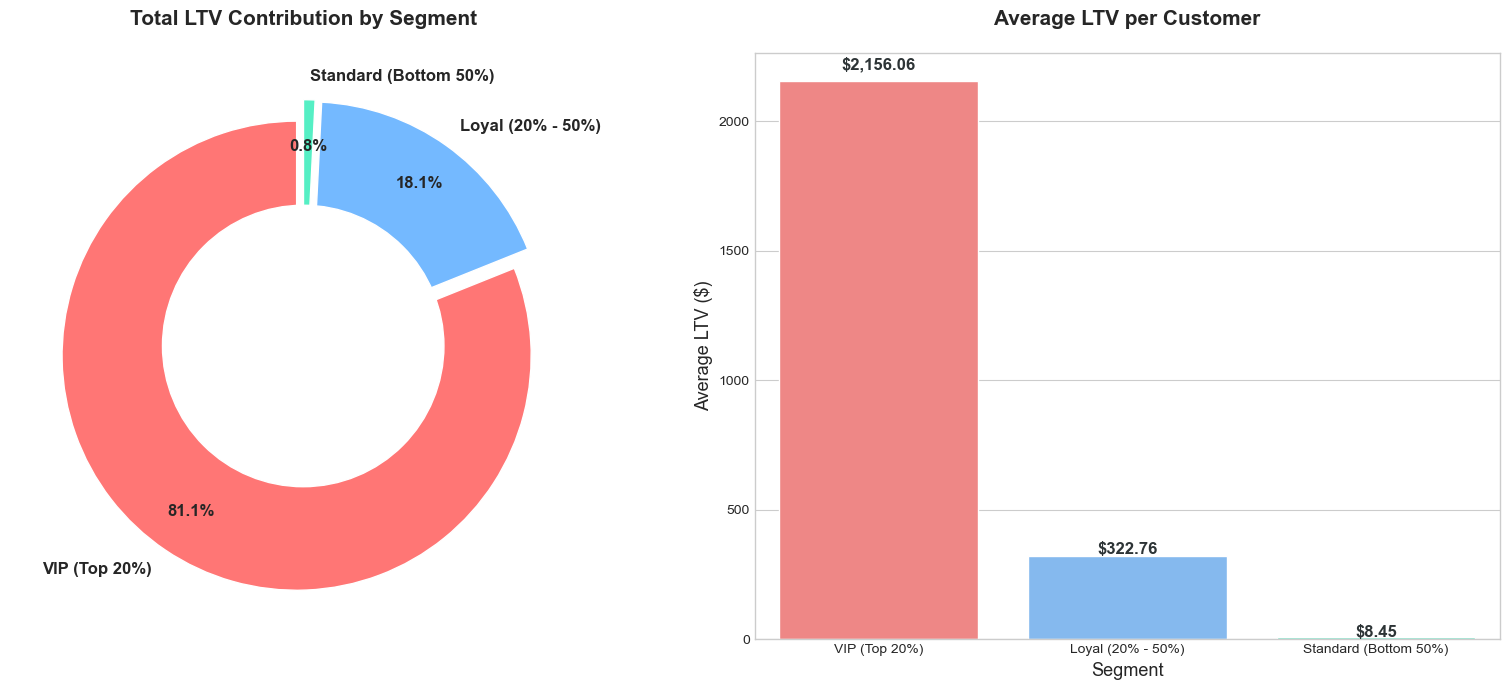

In [27]:
# =========================================================
# 16. Customer Segmentation based on LTV
# =========================================================

# Dự báo LTV cho toàn bộ khách hàng và tạo dataframe
y_pred_all = best_model_estimator.predict(X)
y_pred_all = np.maximum(y_pred_all, 0)
top_customers = ml_df.copy()
top_customers['predicted_clv'] = y_pred_all
# ---------------------------------------------------------------

# Extract CustomerID and predicted_clv (LTV)
ltv_df = top_customers[['CustomerID', 'predicted_clv']].copy()
ltv_df.rename(columns={'predicted_clv': 'LTV'}, inplace=True)

# ---------------------------------------------------------
# Customer Segmentation based on LTV
# ---------------------------------------------------------
# Use the rank function to rank customers, then divide into 3 groups:
# - VIP (Top 20% highest)
# - Loyal (20% to 50%)
# - Standard (Bottom 50%)

ltv_df['Rank'] = ltv_df['LTV'].rank(pct=True)

def assign_ltv_segment(rank):
    if rank >= 0.8:
        return 'VIP (Top 20%)'
    elif rank >= 0.5:
        return 'Loyal (20% - 50%)'
    else:
        return 'Standard (Bottom 50%)'

ltv_df['Segment'] = ltv_df['Rank'].apply(assign_ltv_segment)

# ---------------------------------------------------------
# Segment Analysis
# ---------------------------------------------------------
# Calculate total customers, total LTV, and average LTV for each segment
segment_analysis = ltv_df.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_LTV=('LTV', 'sum'),
    Average_LTV=('LTV', 'mean')
).reset_index()

# Calculate the percentage contribution of LTV for each segment to the total expected revenue
total_ltv_sum = segment_analysis['Total_LTV'].sum()
segment_analysis['LTV_Contribution_Pct'] = (segment_analysis['Total_LTV'] / total_ltv_sum) * 100

# Sort the segments from highest to lowest
sort_mapping = {'VIP (Top 20%)': 1, 'Loyal (20% - 50%)': 2, 'Standard (Bottom 50%)': 3}
segment_analysis['Sort'] = segment_analysis['Segment'].map(sort_mapping)
segment_analysis = segment_analysis.sort_values('Sort').drop('Sort', axis=1)

print("CUSTOMER SEGMENTATION ANALYSIS BASED ON LTV:")
print("="*85)
print(segment_analysis.to_string(index=False))
print("="*85)

# ---------------------------------------------------------
# Visualize the contribution of each segment
# ---------------------------------------------------------
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")
colors = ['#ff7675', '#74b9ff', '#55efc4']

# 1. Donut Chart: LTV Contribution Percentage (%)
ax1 = plt.subplot(1, 2, 1)
explode = (0.05, 0.05, 0.05)
plt.pie(segment_analysis['Total_LTV'], 
        labels=segment_analysis['Segment'], 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=colors, 
        explode=explode, 
        pctdistance=0.80, 
        textprops={'fontsize': 12, 'weight': 'bold'})

# Draw a white circle in the center to create a Donut Chart effect
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Total LTV Contribution by Segment', fontsize=15, weight='bold', pad=20)

# 2. Bar Chart: Average LTV per customer in the segment
ax2 = plt.subplot(1, 2, 2)
sns.barplot(x='Segment', y='Average_LTV', hue='Segment', data=segment_analysis, palette=colors, ax=ax2, legend=False)

# Print specific amounts on top of each bar
for i, v in enumerate(segment_analysis['Average_LTV']):
    ax2.text(i, v + (v*0.02), f'${v:,.2f}', ha='center', fontsize=12, fontweight='bold', color='#2d3436')

plt.title('Average LTV per Customer', fontsize=15, weight='bold', pad=20)
plt.xlabel('Segment', fontsize=13)
plt.ylabel('Average LTV ($)', fontsize=13)

plt.tight_layout()
plt.show()


## Báo cáo Khai thác Tiềm năng LTV Dự báo & Chiến lược Đón đầu

###  Insights


**Sức mạnh dự kiến của nhóm VIP:** Khác với việc nhìn vào doanh thu cũ, mô hình chỉ ra rằng chỉ 20% tệp khách hàng hiện tại đang nắm giữ tới **81.1% dòng tiền tương lai** của doanh nghiệp. Đây là "doanh thu cầm chắc trong tay" nếu chúng ta không làm phật lòng họ trong quý tới.


**Khoảng cách kỳ vọng (Expected Value Gap):** Mô hình dự báo sự phân hóa cực đoan về sức mua sắp tới. Trong 90 ngày tới, một khách hàng VIP dự kiến sẽ "bơm" vào hệ thống $2,156, trong khi một khách hàng thuộc nửa dưới (Standard) được dự báo gần như sẽ "ngủ đông" hoặc rời bỏ với mức chi tiêu chưa tới bát phở ($8.45).
* **Cảnh báo về Chi phí Cơ hội ở nhóm Standard:** Biểu đồ Bar Chart gióng lên một hồi chuông cảnh báo: 50% lượng khách hàng trong Database của chúng ta (nhóm Standard) đã cạn kiệt tiềm năng khai thác. Nếu tiếp tục duy trì ngân sách remarketing cào bằng cho nhóm này trong 90 ngày tới, doanh nghiệp chắc chắn sẽ có ROI âm.

### 2. Actionable Recommendations

Dựa trên nguyên tắc *"Đầu tư vào tương lai, cắt lỗ ở hiện tại"*, kế hoạch hành động trong 90 ngày tới cần được triển khai như sau:

**💎 Nhóm VIP (Bảo vệ Doanh thu Kỳ vọng - Revenue Protection)**
- **Mục tiêu:** Đảm bảo con số $523,923 (81.1%) dự báo kia biến thành tiền thật. Không được phép để xảy ra bất kỳ sự cố CSKH nào với nhóm này.
- **Hành động:** 
  - Khởi động ngay chiến dịch "VIP Care" trước khi 90 ngày kết thúc: Cử nhân viên gọi điện hỏi thăm, gửi tặng e-voucher giá trị cao không kèm điều kiện.
  - Áp dụng whitelist: Loại trừ nhóm này khỏi các chiến dịch xả kho giảm giá sâu để bảo vệ định vị thương hiệu cao cấp trong mắt họ.

**🤝 Nhóm Loyal (Kích cầu Tương lai - Growth & Incubation)**
- **Mục tiêu:** Mức dự báo $322/người cho thấy họ vẫn có nhu cầu mua sắm nhưng chưa đạt đỉnh. Chúng ta cần các chiến dịch "kích thích" để ép con số thực tế vượt mức dự báo của mô hình.
- **Hành động:**
  - Kích hoạt hệ thống "Product Recommendation" (Gợi ý sản phẩm) dựa trên lịch sử mua cũ để tạo nhu cầu mới.
  - Tạo các chiến dịch Flash Sale hoặc Combo "Mua 2 tặng 1" dành riêng cho nhóm này để thúc đẩy họ tăng giá trị đơn hàng (AOV).

**👥 Nhóm Standard (Cắt giảm Ngân sách - Budget Reallocation)**
- **Mục tiêu:** Ngừng chảy máu dòng tiền Marketing vào nhóm không có tiềm năng tương lai.
- **Hành động:**
  - Lập tức loại trừ (Exclude) tệp 605 khách hàng này khỏi tất cả các chiến dịch quảng cáo trả phí (Facebook/Google Ads) trong quý tới.
  - Chuyển họ vào phễu Email/SMS tự động (Automated Drip Campaigns) với tần suất thưa thớt để "đánh bắt xa bờ" với chi phí 0 đồng.
  - **Dịch chuyển ngân sách:** Dùng số tiền vừa tiết kiệm được từ nhóm này để tái đầu tư vào việc tìm kiếm khách hàng mới (Acquisition) có profile giống với nhóm VIP.
